In [19]:
import pandas as pd
import spacy
from IPython.core.magic import register_cell_magic
from google_play_scraper import reviews_all
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
@register_cell_magic
def skip(line, cell):
    return

przygotowanie danych

In [3]:
%%skip
languages = ["pl"]
apps_ids = ["pl.mapa_turystyczna.app"]

parsed_list = []

for app_id in apps_ids:
    for lang in languages:
        parsed_dict = reviews_all(app_id=app_id, sleep_milliseconds=1200, lang=lang)
        partial_df = pd.DataFrame(parsed_dict).assign(appId=app_id, language=lang)
        partial_df = partial_df.drop(columns=["userImage", "userName"])
        parsed_list.append(partial_df)

df = pd.concat(parsed_list)
df.to_csv("reviews_data.csv")

In [4]:
df = pd.read_csv("reviews_data.csv", index_col="index")

przetwarzanie danych językowych

In [5]:
nlp = spacy.load("pl_core_news_lg")


def lemmatize(text):
    if pd.isna(text):
        return ""
    doc = nlp(str(text).lower())

    lemmas = [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]

    return " ".join(lemmas)

In [6]:
def get_ngram_counts(
    df: pd.DataFrame, text_col: str = "lemmas", ngram_range: tuple = (2,3), min_size: int = 5
):
    print("starting conversion")

    vectorizer = CountVectorizer(ngram_range=ngram_range, min_df=min_size)
    X = vectorizer.fit_transform(df[text_col])

    ngram_counts = pd.DataFrame(
        X.sum(axis=0).T, index=vectorizer.get_feature_names_out(), columns=["count"]
    )
    return ngram_counts

def backwards_ngram(df, phrase, text_col: str = "lemmas"):
    results = df[df[text_col].str.contains(phrase, na=False)]
    print(f"found {len(results)} reviews for the phrase '{phrase}'")
    return results

In [ ]:
bad_reviews = df[df["score"] <=2].assign(lemmas = lambda x: x["content"].apply(lemmatize))

In [15]:
ngram = get_ngram_counts(bad_reviews).sort_values(by="count", ascending=False)
ngram

starting conversion


,count
mapa offline,35
wersja premium,24
planować trasa,21
na przykład,21
mapa turystyczny,20
brak możliwość,20
pobrać mapa,16
zaplanować trasa,13
mapa google,12
google maps,11


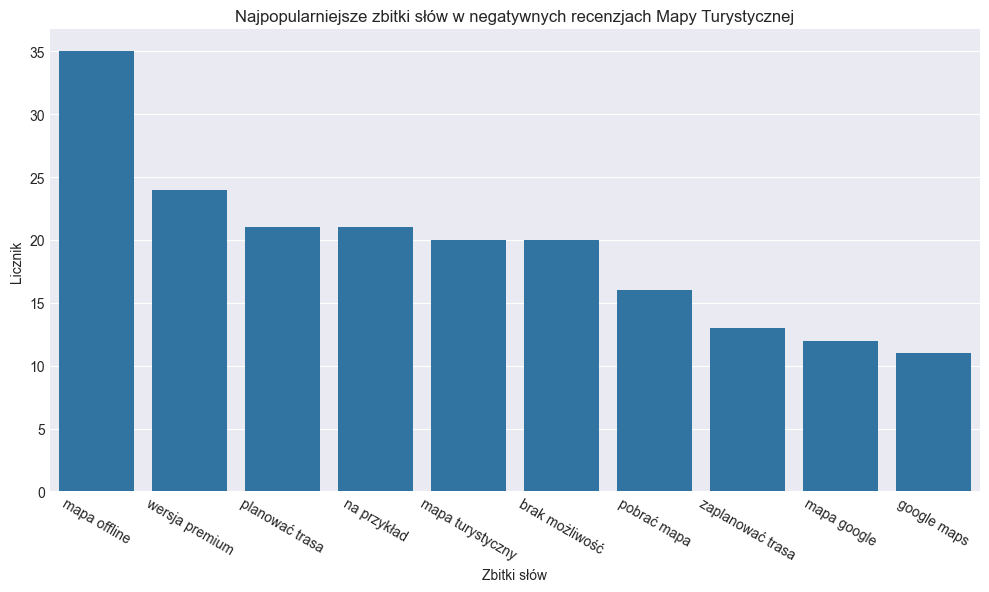

In [33]:
ngram_short = ngram.head(10)

plt.figure(figsize=(12,6))
ax = (sns.barplot(data=ngram_short, x=ngram_short.index, y="count"))

ax.set_xticks(range(len(ngram_short)))
ax.set_xticklabels(rotation=-30, labels=ngram_short.index)
ax.set_title("Najpopularniejsze zbitki słów w negatywnych recenzjach Mapy Turystycznej")
ax.set_ylabel("Licznik")
ax.set_xlabel("Zbitki słów")
plt.show()